In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Logistics Data Analysis Project")
print("Python environment working successfully!")

Logistics Data Analysis Project
Python environment working successfully!


In [2]:
orders = pd.read_csv(
    "../data/raw/olist_orders_dataset.csv"
)

customers = pd.read_csv(
    "../data/raw/olist_customers_dataset.csv"
)

items = pd.read_csv(
    "../data/raw/olist_order_items_dataset.csv"
)

products = pd.read_csv(
    "../data/raw/olist_products_dataset.csv"
)

reviews = pd.read_csv(
    "../data/raw/olist_order_reviews_dataset.csv"
)

In [3]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Items:", items.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [8]:
date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

In [9]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [10]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

In [11]:
average_delivery_time = orders["delivery_days"].mean()

print(
    "Average Delivery Time:",
    round(average_delivery_time, 2),
    "days"
)

Average Delivery Time: 12.56 days


In [12]:
orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [13]:
orders["on_time"] = orders["delay_days"] <= 0

In [14]:
on_time_rate = orders["on_time"].mean() * 100

print(
    "On-Time Delivery Rate:",
    round(on_time_rate, 2),
    "%"
)

On-Time Delivery Rate: 89.15 %


In [15]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [16]:
average_freight = items["freight_value"].mean()

print(
    "Average Freight Cost:",
    round(average_freight, 2)
)

Average Freight Cost: 19.99


In [17]:
reviews["review_score"].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [18]:
average_review = reviews["review_score"].mean()

print(
    "Average Review Score:",
    round(average_review, 2)
)

Average Review Score: 4.09


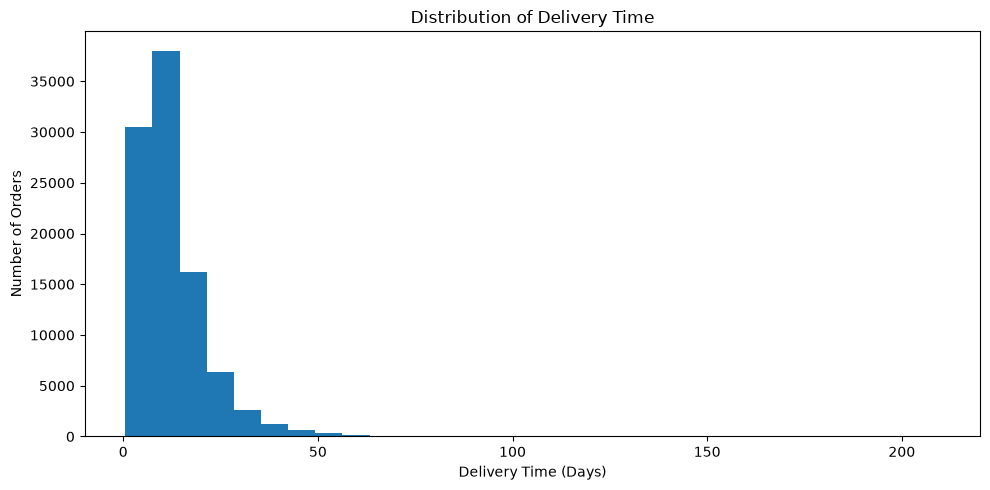

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(
    orders["delivery_days"].dropna(),
    bins=30
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [20]:
plt.savefig(
    "../screenshots/delivery_time_distribution.png"
)

<Figure size 640x480 with 0 Axes>

In [21]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

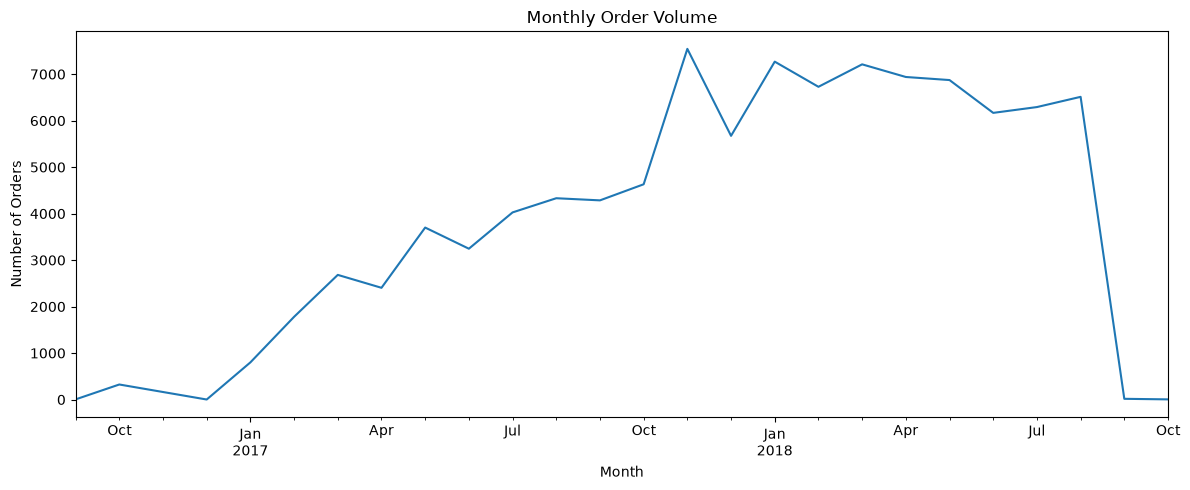

In [22]:
monthly_orders = (
    orders.groupby("purchase_month")
    ["order_id"]
    .count()
)

monthly_orders.plot(
    figsize=(12, 5)
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [23]:
plt.savefig(
    "../screenshots/monthly_orders.png"
)

<Figure size 640x480 with 0 Axes>

In [24]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [25]:
top_states = (
    customers["customer_state"]
    .value_counts()
    .head(10)
)

print(top_states)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


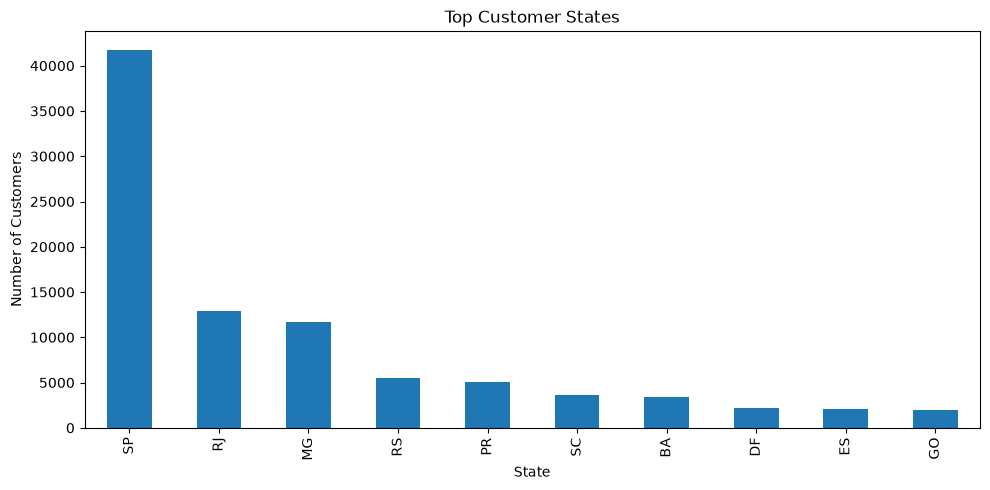

In [26]:
top_states.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()